In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.impute import SimpleImputer

In [2]:
df = pd.read_csv("/Users/parthporiya/Documents/DSBDA_Practical/heart_disease_uci.csv")

In [3]:
print(df.head())

   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4             normal    0  


In [4]:
print(df.shape)

(920, 16)


In [5]:
# Data Cleaning
print("Missing values in each column:\n",df.isnull().sum())

Missing values in each column:
 id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


In [6]:
df.drop_duplicates(inplace=True)

In [7]:
print("Datatypes: \n",df.dtypes)

Datatypes: 
 id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
dtype: object


In [8]:
#performing data cleaning and error correcting
pd.set_option('future.no_silent_downcasting',True)

In [9]:
mean_columns = ['trestbps' , 'chol' , 'thalch' , 'oldpeak' , 'ca']
mode_columns = ['fbs' , 'restecg' , 'exang' , 'slope' , 'thal']

In [10]:
for col in mean_columns:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mean())
#we performed a command where all the numeric columns where null values were present
#were filled with the mean 

In [11]:
for col in mode_columns:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])
#we have done the same as before but this time for categorical values

In [12]:
df = df.infer_objects(copy = False)
#converts columns that may be an object into the nearest possible datatype
#library might work the best

In [13]:
print("The number of missing values in each column is : \n", df.isna().sum())

The number of missing values in each column is : 
 id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


In [14]:
df['hospital_id'] = np.random.randint(100, 105, size=len(df))

In [15]:
df1 = df[['age', 'cp', 'chol']]
df2 = df[['thalch', 'exang', 'num']]

merged_df = pd.concat([df1, df2], axis=1)

print(merged_df.head())

   age               cp   chol  thalch  exang  num
0   63   typical angina  233.0   150.0  False    0
1   67     asymptomatic  286.0   108.0   True    2
2   67     asymptomatic  229.0   129.0   True    1
3   37      non-anginal  250.0   187.0  False    0
4   41  atypical angina  204.0   172.0  False    0


In [16]:
print("Shape of Merged DataFrame:", merged_df.shape)
print("Columns:", merged_df.columns.tolist())

Shape of Merged DataFrame: (920, 6)
Columns: ['age', 'cp', 'chol', 'thalch', 'exang', 'num']


In [17]:
#removal of outliers using the IQR method

def mark_outliers(column):
    #we check if the coluns is numeric(integer, unsigned, float, complex)
    if column.dtype.kind in 'iufc':
        Q1 = column.quantile(0.25)
        Q3 = column.quantile(0.75)
        IQR = Q3 - Q1
        threshold = 1.5 * IQR

        #boolean mask for the outliers
        outlier_mask = (column < Q1 - threshold) | (column > Q3 + threshold)

        #return only outliers, anything other than outliers become NaN values
        return column.where(outlier_mask)
    else:
        #non-numeric columns to be returned as is 
        return column

In [18]:
numeric_columns = ['age', 'trestbps' , 'chol' , 'thalch' , 'oldpeak' , 'ca']

In [19]:
for col in numeric_columns:
    if col in df.columns:
        df[f'{col}_outliers'] = mark_outliers(df[col])
#the above will create new columns for marked outliers 

In [20]:
outlier_columns = [f'{col}_outliers' for col in numeric_columns]

In [21]:
outliers_df = df[outlier_columns].dropna(how = 'all')

In [22]:
print("Rows with outliers: \n", outliers_df)

Rows with outliers: 
      age_outliers  trestbps_outliers  chol_outliers  thalch_outliers  \
0             NaN                NaN            NaN              NaN   
1             NaN                NaN            NaN              NaN   
2             NaN                NaN            NaN              NaN   
3             NaN                NaN            NaN              NaN   
4             NaN                NaN            NaN              NaN   
..            ...                ...            ...              ...   
841           NaN                NaN            NaN              NaN   
854           NaN              172.0            NaN              NaN   
863           NaN                NaN            NaN              NaN   
889           NaN              180.0            NaN              NaN   
896           NaN              190.0            NaN              NaN   

     oldpeak_outliers  ca_outliers  
0                 NaN          0.0  
1                 NaN          3.0  
2 

In [23]:
# to remove the outliers 

def remove_outliers(df, column):
    # check if the column is numeric
    if df[column].dtype.kind in 'iufc':
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df_clean = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    
        return df_clean
    else:
        return df

In [24]:
df_clean = df  # safer than df = df

for col in numeric_columns:
    if col in df_clean.columns:
        df_clean = remove_outliers(df_clean, col)

print("Cleaned Dataframe without the outliers:\n", df_clean)


Cleaned Dataframe without the outliers:
       id  age     sex        dataset               cp    trestbps   chol  \
166  167   52    Male      Cleveland      non-anginal  138.000000  223.0   
192  193   43    Male      Cleveland     asymptomatic  132.000000  247.0   
287  288   58    Male      Cleveland  atypical angina  125.000000  220.0   
302  303   38    Male      Cleveland      non-anginal  138.000000  175.0   
303  304   28    Male      Cleveland  atypical angina  130.000000  132.0   
..   ...  ...     ...            ...              ...         ...    ...   
915  916   54  Female  VA Long Beach     asymptomatic  127.000000  333.0   
916  917   62    Male  VA Long Beach   typical angina  132.132404  139.0   
917  918   55    Male  VA Long Beach     asymptomatic  122.000000  223.0   
918  919   58    Male  VA Long Beach     asymptomatic  132.132404  385.0   
919  920   62    Male  VA Long Beach  atypical angina  120.000000  254.0   

       fbs           restecg      thalch  ... 

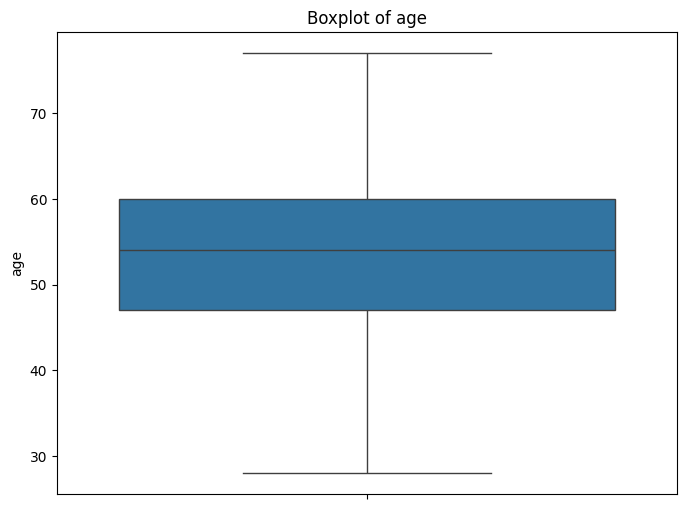

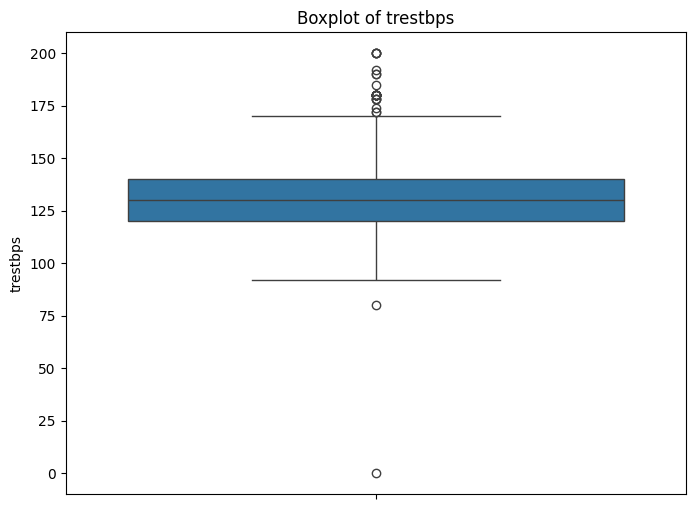

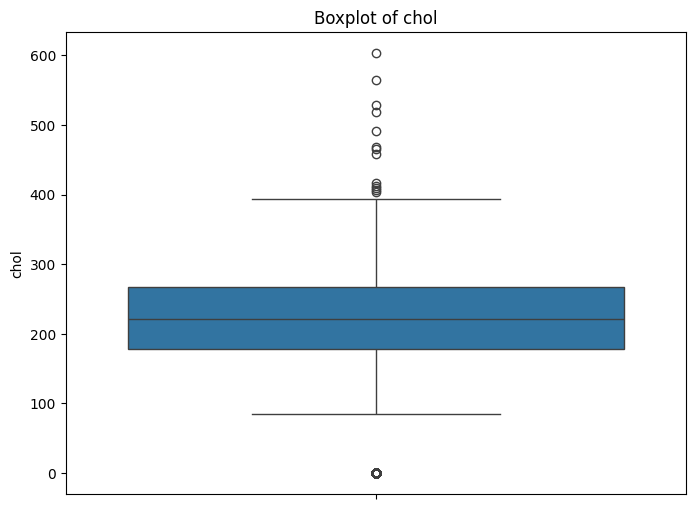

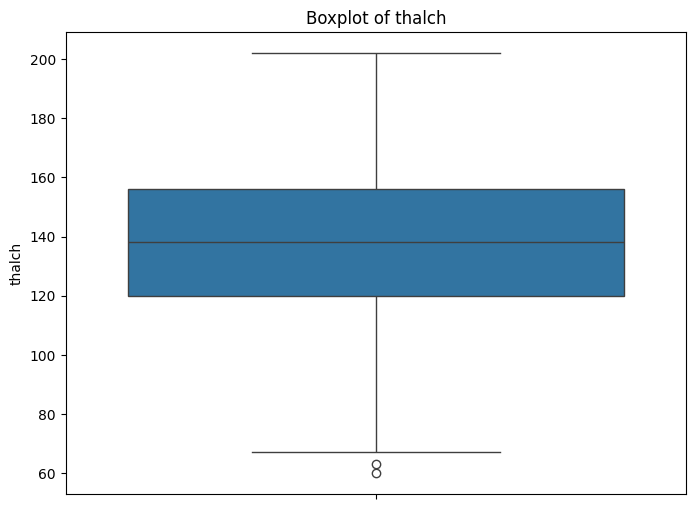

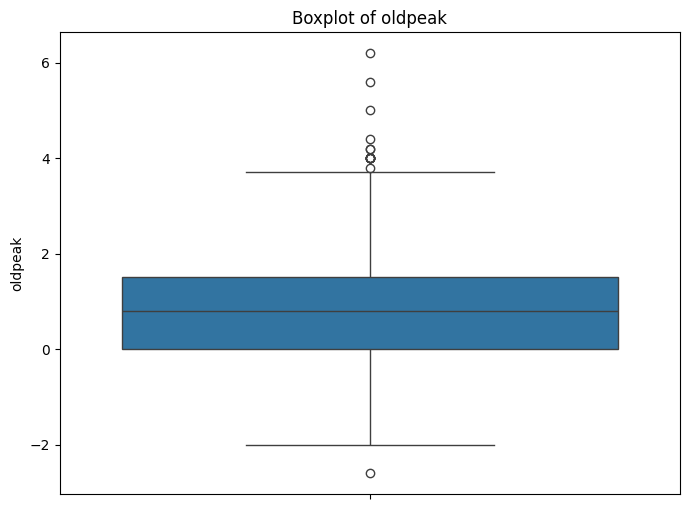

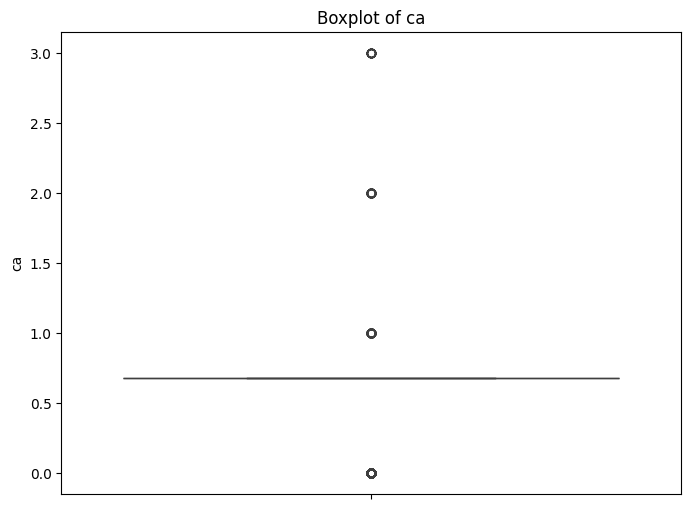

In [25]:
for col in numeric_columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [26]:
df['cp'] = df['cp'].replace({
    'typical angina': 'typical_angina',
    'atypical angina': 'atypical_angina'
})

In [27]:
df['restecg'] = df['restecg'].replace({
    'lv hypertrophy': 'left_ventricular_hypertrophy',
    'st-t abnormality': 'ST_T_abnormality'
})

In [28]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))

In [29]:
scaler = StandardScaler()

scale_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

df[scale_cols] = scaler.fit_transform(df[scale_cols])

In [30]:
df = df.drop(columns=[
    'age_outliers',
    'trestbps_outliers',
    'chol_outliers',
    'thalch_outliers',
    'oldpeak_outliers',
    'ca_outliers'
], errors='ignore')

In [31]:
X = df.drop('num', axis=1)

y = (df['num'] > 0).astype(int)

In [32]:
imputer = SimpleImputer(strategy='mean')

X = imputer.fit_transform(X)


In [33]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [36]:
y_pred = model.predict(X_test)

In [37]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7989130434782609


In [38]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[62 13]
 [24 85]]
